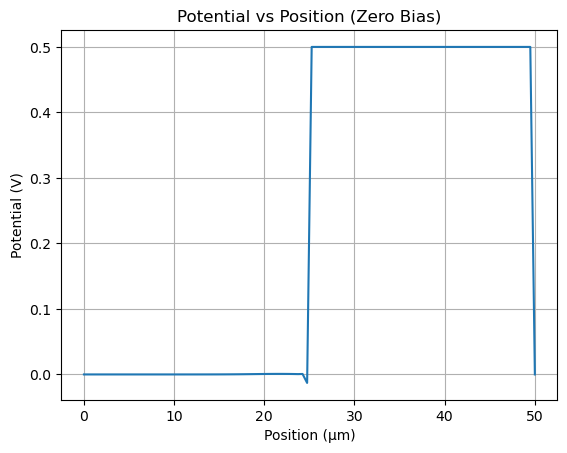

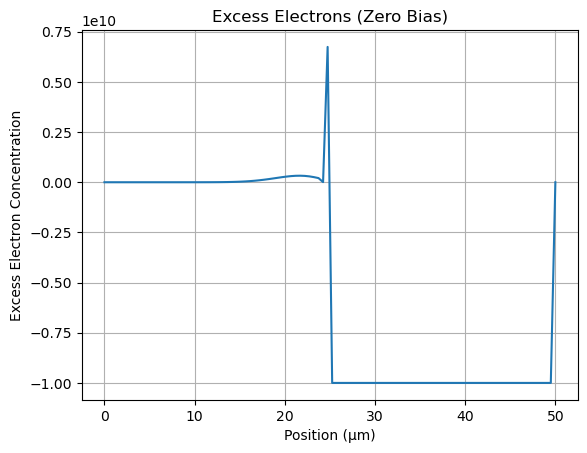

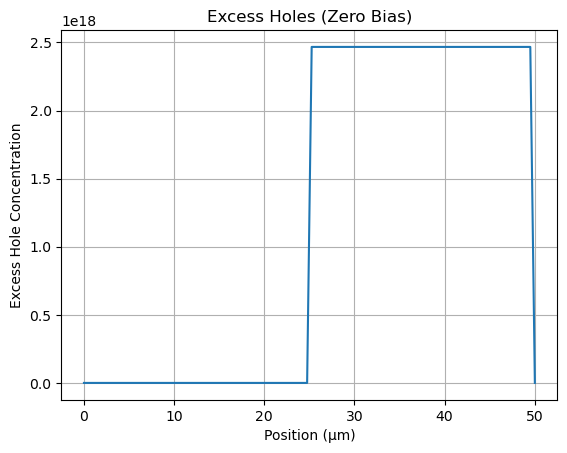

In [3]:
# Question 1

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Physical constants
# ---------------------------------
q = 1.6e-19                 # Electron charge (C)
k = 1.38e-23                # Boltzmann constant (J/K)
T = 300                     # Temperature (K)
VT = k*T/q                  # Thermal voltage (~0.026 V)

eps0 = 8.85e-14             # Permittivity of free space (F/cm)
eps_si = 11.7 * eps0        # Silicon permittivity (F/cm)

ni = 1e10                   # Intrinsic carrier concentration (cm^-3)

# ---------------------------------
# Mesh
# ---------------------------------
L = 50e-4                   # Device length = 50 um (in cm)
N = 100                     # Number of grid points
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# ---------------------------------
# Doping profile (Resistor)
# Step donor doping at x = 25 um
# ---------------------------------
ND = np.zeros(N)
NA = np.zeros(N)

ND[x >= L/2] = 1e16         # Donor concentration (cm^-3)

# ---------------------------------
# Initial potential
# ---------------------------------
psi = np.zeros(N)

# ---------------------------------
# Poisson Solver (Finite Difference)
# ---------------------------------
for _ in range(500):

    n = ni * np.exp(np.clip(psi/VT, -40, 40))
    p = ni * np.exp(np.clip(-psi/VT, -40, 40))

    for i in range(1, N-1):
        rho = q * (p[i] - n[i] + ND[i] - NA[i])

        psi_new = 0.5 * (psi[i+1] + psi[i-1] + dx*dx*rho/eps_si)
        psi[i] = 0.9 * psi[i] + 0.1 * psi_new

        psi[i] = np.clip(psi[i], -0.5, 0.5)

    psi[0] = 0
    psi[-1] = 0


# ---------------------------------
# Excess carriers
# ---------------------------------
delta_n = n - ni
delta_p = p - ni

# ---------------------------------
# Plots
# ---------------------------------
x_um = x * 1e4              # Convert cm → um

plt.figure()
plt.plot(x_um, psi)
plt.xlabel("Position (µm)")
plt.ylabel("Potential (V)")
plt.title("Potential vs Position (Zero Bias)")
plt.grid()
plt.show()

plt.figure()
plt.plot(x_um, delta_n)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Electron Concentration")
plt.title("Excess Electrons (Zero Bias)")
plt.grid()
plt.show()

plt.figure()
plt.plot(x_um, delta_p)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Hole Concentration")
plt.title("Excess Holes (Zero Bias)")
plt.grid()
plt.show()



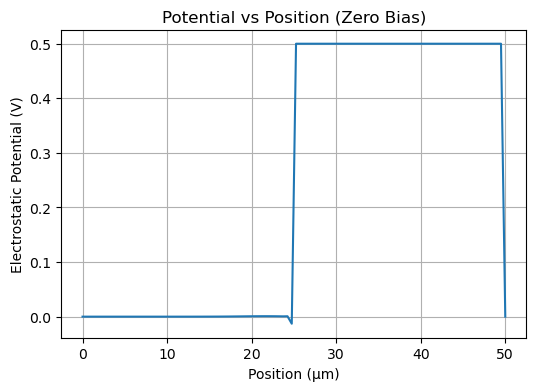

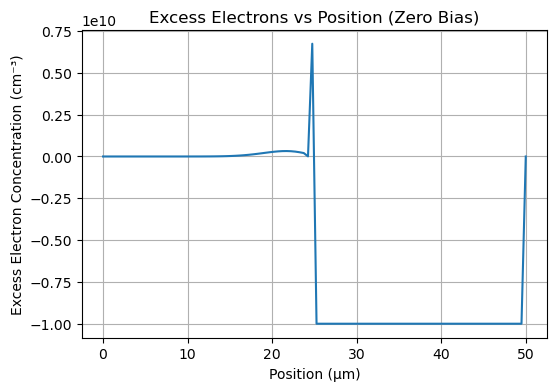

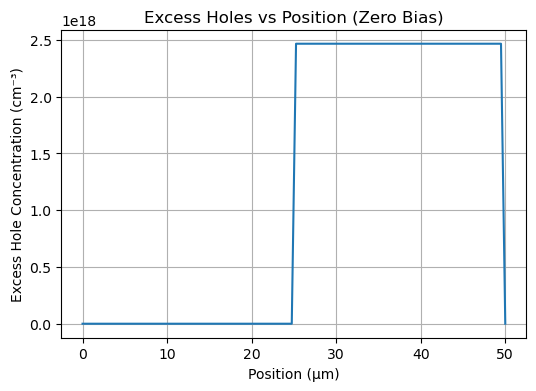

In [4]:
# ---------------------------------
# Question 2: Zero-bias analysis
# ---------------------------------

# Excess carrier concentrations
delta_n = n - ni
delta_p = p - ni

# Convert position to micrometers
x_um = x * 1e4

# Potential vs position
plt.figure(figsize=(6,4))
plt.plot(x_um, psi)
plt.xlabel("Position (µm)")
plt.ylabel("Electrostatic Potential (V)")
plt.title("Potential vs Position (Zero Bias)")
plt.grid(True)
plt.show()

# Excess electrons vs position
plt.figure(figsize=(6,4))
plt.plot(x_um, delta_n)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Electron Concentration (cm⁻³)")
plt.title("Excess Electrons vs Position (Zero Bias)")
plt.grid(True)
plt.show()

# Excess holes vs position
plt.figure(figsize=(6,4))
plt.plot(x_um, delta_p)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Hole Concentration (cm⁻³)")
plt.title("Excess Holes vs Position (Zero Bias)")
plt.grid(True)
plt.show()


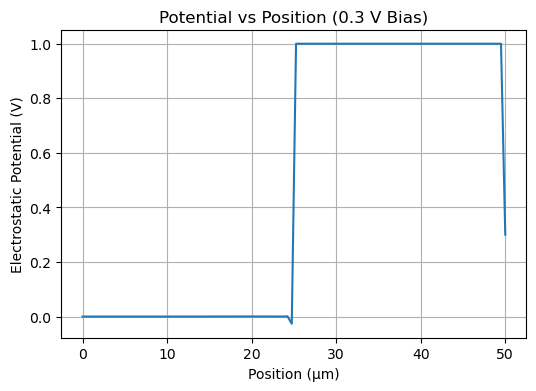

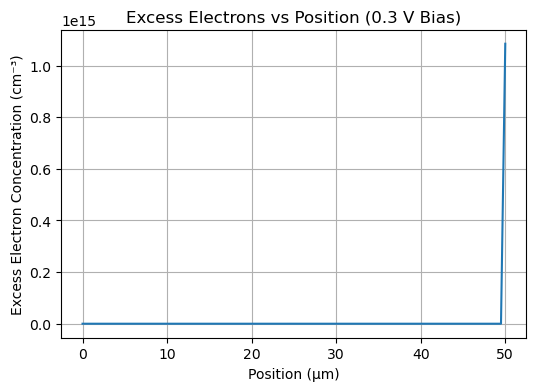

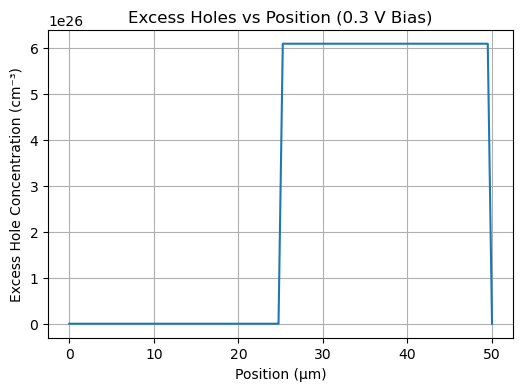

In [5]:
# ---------------------------------
# Question 3: Apply 0.3 V bias
# ---------------------------------

# Apply bias at contacts
V_app = 0.3
psi[0]  = 0.0
psi[-1] = V_app

# Poisson solver with applied bias
for _ in range(500):

    n = ni * np.exp(np.clip(psi/VT, -40, 40))
    p = ni * np.exp(np.clip(-psi/VT, -40, 40))

    for i in range(1, N-1):
        rho = q * (p[i] - n[i] + ND[i] - NA[i])
        psi_new = 0.5 * (psi[i+1] + psi[i-1] + dx*dx*rho/eps_si)
        psi[i] = 0.9 * psi[i] + 0.1 * psi_new
        psi[i] = np.clip(psi[i], -1.0, 1.0)

# Excess carriers
delta_n = n - ni
delta_p = p - ni

# Position in micrometers
x_um = x * 1e4

# Plot potential
plt.figure(figsize=(6,4))
plt.plot(x_um, psi)
plt.xlabel("Position (µm)")
plt.ylabel("Electrostatic Potential (V)")
plt.title("Potential vs Position (0.3 V Bias)")
plt.grid(True)
plt.show()

# Plot excess electrons
plt.figure(figsize=(6,4))
plt.plot(x_um, delta_n)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Electron Concentration (cm⁻³)")
plt.title("Excess Electrons vs Position (0.3 V Bias)")
plt.grid(True)
plt.show()

# Plot excess holes
plt.figure(figsize=(6,4))
plt.plot(x_um, delta_p)
plt.xlabel("Position (µm)")
plt.ylabel("Excess Hole Concentration (cm⁻³)")
plt.title("Excess Holes vs Position (0.3 V Bias)")
plt.grid(True)
plt.show()


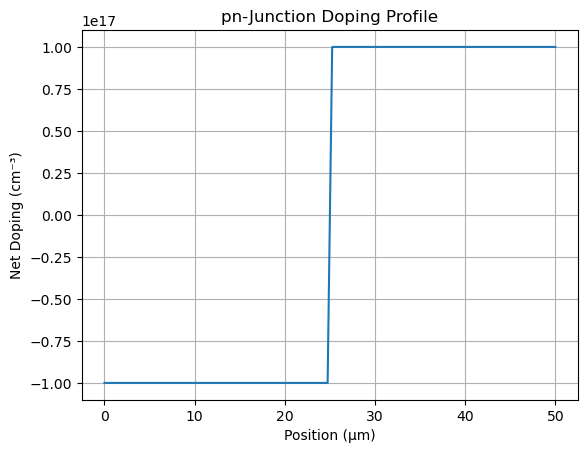

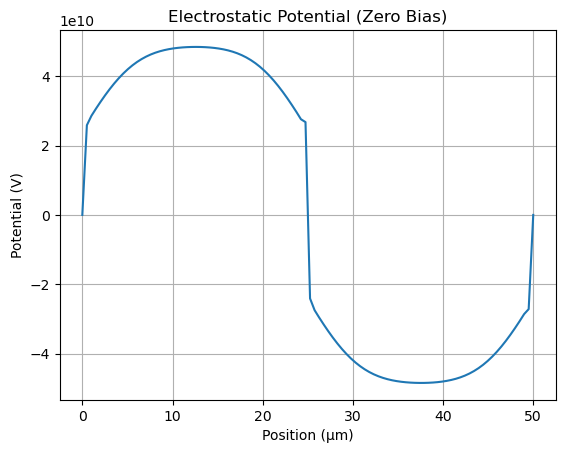

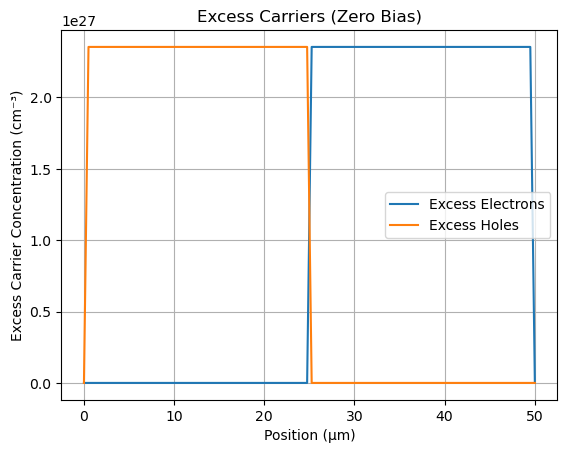

In [6]:
# Question 5

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Physical constants
# ---------------------------------
q = 1.6e-19
k = 1.38e-23
T = 300
VT = k*T/q

eps0 = 8.85e-14
eps_si = 11.7 * eps0

ni = 1e10

# ---------------------------------
# Mesh
# ---------------------------------
L = 50e-4            # 50 µm in cm
N = 100
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# ---------------------------------
# pn-junction doping profile
# Junction at middle (25 µm)
# ---------------------------------
ND = np.zeros(N)
NA = np.zeros(N)

ND[x >= L/2] = 1e17      # n-region
NA[x <  L/2] = 1e17      # p-region

# Net doping
net_doping = ND - NA

# ---------------------------------
# Initial potential
# ---------------------------------
psi = np.zeros(N)

# ---------------------------------
# Zero-bias boundary conditions
# ---------------------------------
psi[0] = 0.0
psi[-1] = 0.0

# ---------------------------------
# Poisson Solver
# ---------------------------------
for _ in range(800):

    n = ni * np.exp(np.clip(psi/VT, -40, 40))
    p = ni * np.exp(np.clip(-psi/VT, -40, 40))

    for i in range(1, N-1):
        rho = q * (p[i] - n[i] + ND[i] - NA[i])
        psi_new = 0.5 * (psi[i+1] + psi[i-1] + dx*dx*rho/eps_si)
        psi[i] = 0.9 * psi[i] + 0.1 * psi_new

# ---------------------------------
# Excess carriers
# ---------------------------------
delta_n = n - ni
delta_p = p - ni

# ---------------------------------
# Plots
# ---------------------------------
x_um = x * 1e4

plt.figure()
plt.plot(x_um, net_doping)
plt.xlabel("Position (µm)")
plt.ylabel("Net Doping (cm⁻³)")
plt.title("pn-Junction Doping Profile")
plt.grid()
plt.show()

plt.figure()
plt.plot(x_um, psi)
plt.xlabel("Position (µm)")
plt.ylabel("Potential (V)")
plt.title("Electrostatic Potential (Zero Bias)")
plt.grid()
plt.show()

plt.figure()
plt.plot(x_um, delta_n, label="Excess Electrons")
plt.plot(x_um, delta_p, label="Excess Holes")
plt.xlabel("Position (µm)")
plt.ylabel("Excess Carrier Concentration (cm⁻³)")
plt.title("Excess Carriers (Zero Bias)")
plt.legend()
plt.grid()
plt.show()


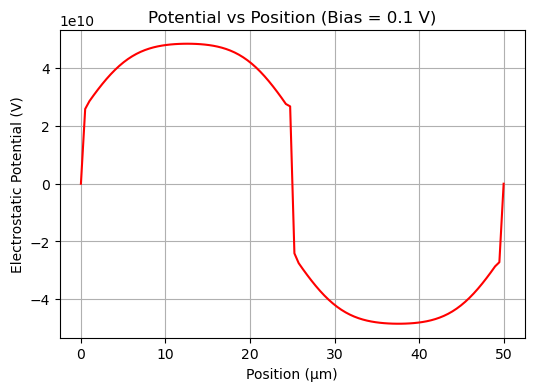

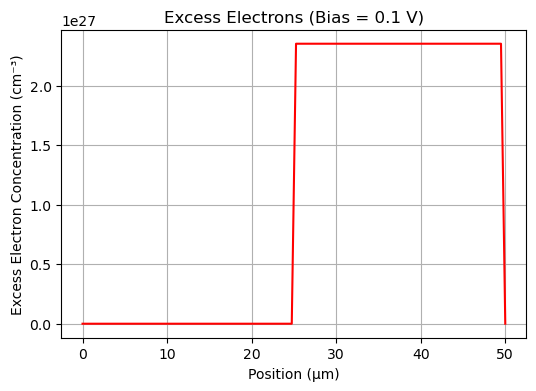

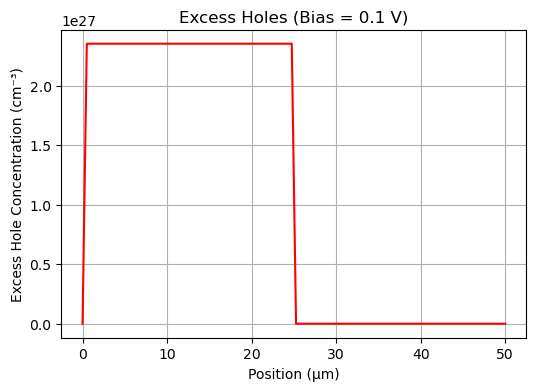

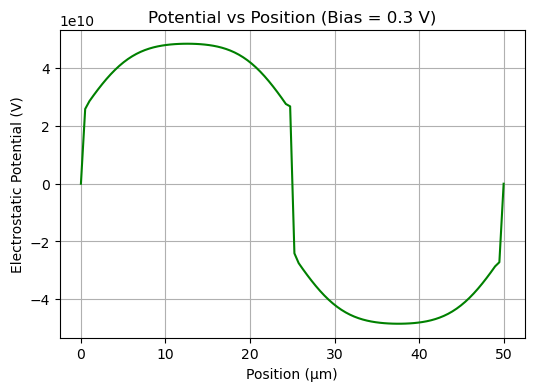

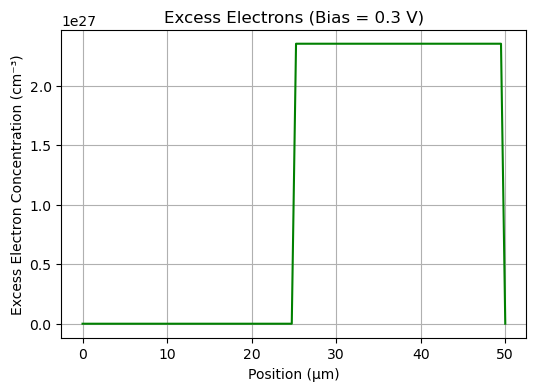

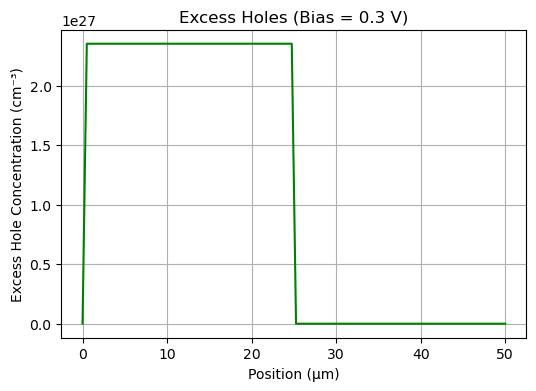

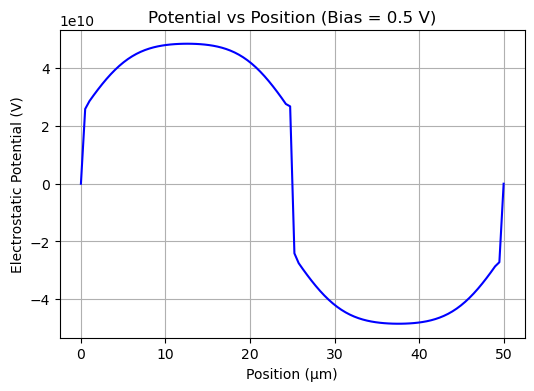

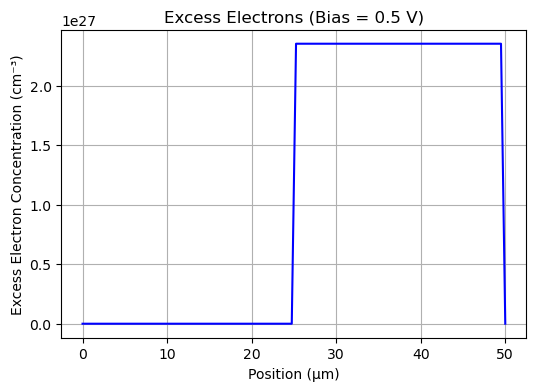

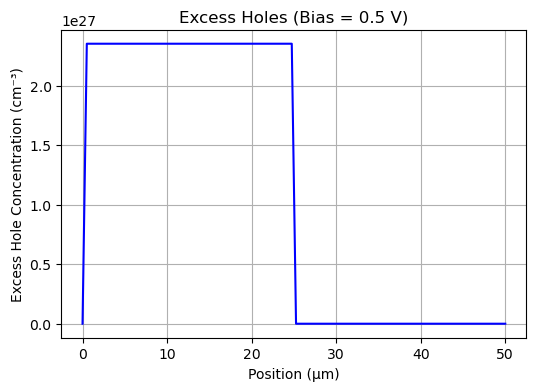

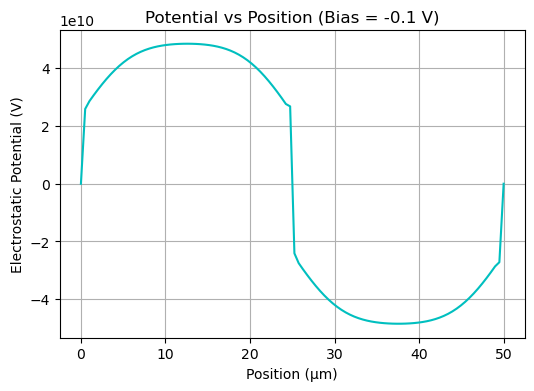

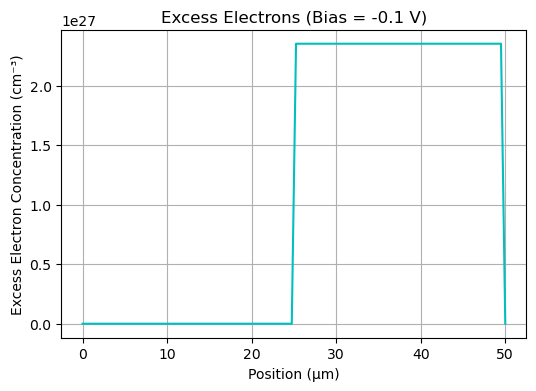

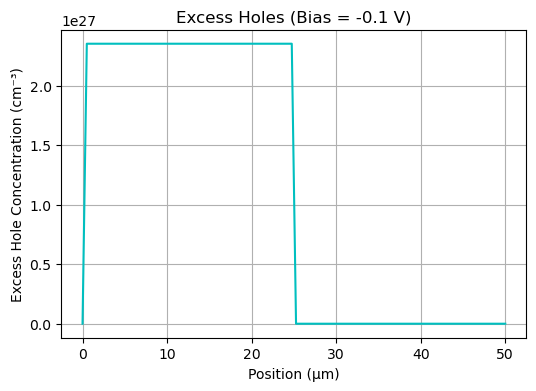

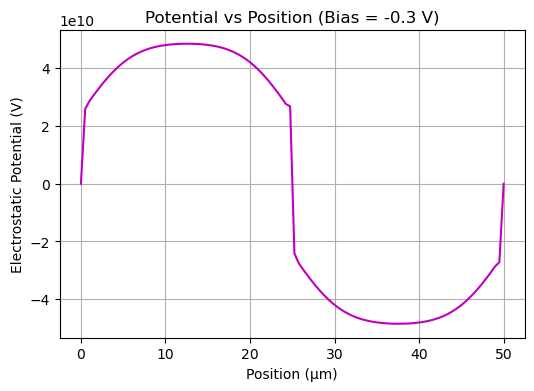

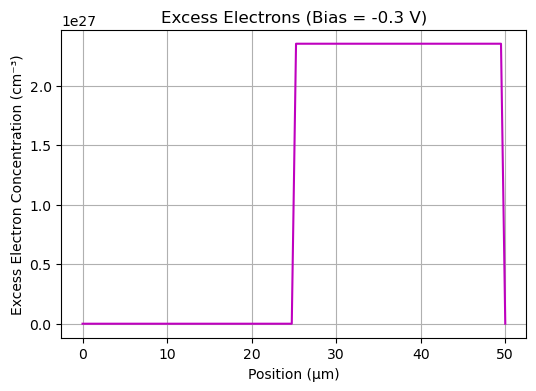

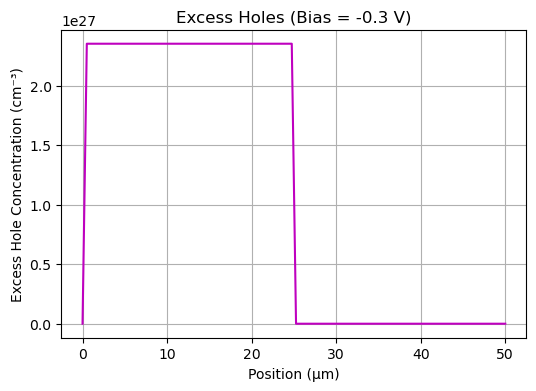

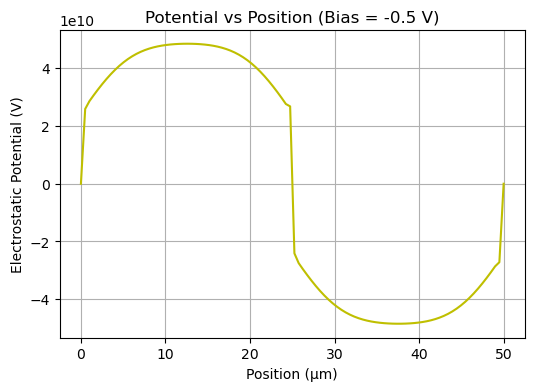

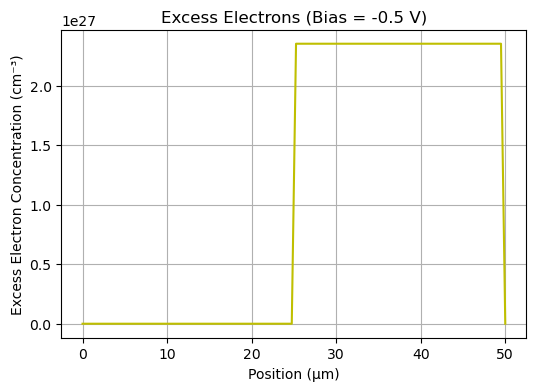

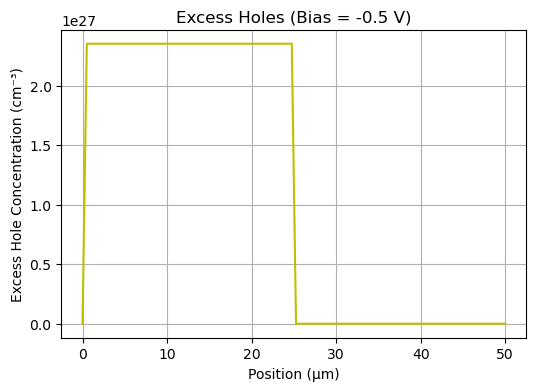

In [7]:
# Question 5
# Bias voltages
# Forward: 0.1, 0.3, 0.5 V
# Reverse: -0.1, -0.3, -0.5 V
# ---------------------------------
bias_list = [0.1, 0.3, 0.5, -0.1, -0.3, -0.5]

# Prepare figure colors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

for idx, V_app in enumerate(bias_list):
    # Reset potential
    psi = np.zeros(N)

    # Apply bias at contacts
    psi[0] = 0.0
    psi[-1] = V_app

    # Poisson solver
    for _ in range(800):
        n = ni * np.exp(np.clip(psi/VT, -40, 40))
        p = ni * np.exp(np.clip(-psi/VT, -40, 40))

        for i in range(1, N-1):
            rho = q * (p[i] - n[i] + ND[i] - NA[i])
            psi_new = 0.5 * (psi[i+1] + psi[i-1] + dx*dx*rho/eps_si)
            psi[i] = 0.9 * psi[i] + 0.1 * psi_new

    # Excess carriers
    delta_n = n - ni
    delta_p = p - ni

    # Convert position to micrometers
    x_um = x * 1e4

    # Plot potential
    plt.figure(figsize=(6,4))
    plt.plot(x_um, psi, color=colors[idx])
    plt.xlabel("Position (µm)")
    plt.ylabel("Electrostatic Potential (V)")
    plt.title(f"Potential vs Position (Bias = {V_app} V)")
    plt.grid()
    plt.show()

    # Plot excess electrons
    plt.figure(figsize=(6,4))
    plt.plot(x_um, delta_n, color=colors[idx])
    plt.xlabel("Position (µm)")
    plt.ylabel("Excess Electron Concentration (cm⁻³)")
    plt.title(f"Excess Electrons (Bias = {V_app} V)")
    plt.grid()
    plt.show()

    # Plot excess holes
    plt.figure(figsize=(6,4))
    plt.plot(x_um, delta_p, color=colors[idx])
    plt.xlabel("Position (µm)")
    plt.ylabel("Excess Hole Concentration (cm⁻³)")
    plt.title(f"Excess Holes (Bias = {V_app} V)")
    plt.grid()
    plt.show()
